# Set GPU

In [1]:
import os

# You can only use one GPU at a time
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["OMP_NUM_THREADS"] = "16"
os.environ["MKL_NUM_THREADS"] = "16"

In [2]:
%%bash
echo "CUDA_VISIBLE_DEVICES: $CUDA_VISIBLE_DEVICES"
echo "OMP_NUM_THREADS: $OMP_NUM_THREADS"
echo "MKL_NUM_THREADS: $MKL_NUM_THREADS"

CUDA_VISIBLE_DEVICES: 0
OMP_NUM_THREADS: 16
MKL_NUM_THREADS: 16


In [3]:
import torch

if torch.cuda.is_available():
    torch.cuda.set_device(0)

    print("CUDA is available.")
    print(f"Number of CUDA devices: {torch.cuda.device_count()}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA is not available.")

CUDA is available.
Number of CUDA devices: 1
Current device: 0
Device name: NVIDIA A100-PCIE-40GB


In [4]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.datasets.folder import default_loader

from vv.data import ImageNetLoader

./venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Model

In [ ]:
# Load your model checkpoint
from vv.models.vqgan_lc_copy.vq_model import VQModel
model_ckpt = "/path/to/additional_evaluations/downloaded_models/models/vq_gan_lc/vqgan_lc_100k_F8_Z4/version_0/checkpoints/latest-step=0/vqgan-lc-100K-f8-dim4-lightning.ckpt"

class_path = "vv.models.vqgan_lc_copy.vq_model.VQModel"
model_args = {
    "learning_rate": 4.5e-06,
    "embed_dim": 4,
    "n_vision_words": 100000,
    "local_embedding_path": "/path/to/additional_evaluations/downloaded_models/models/vq_gan_lc/codebook-100K.pth",
    "tuning_codebook": 0,
    "use_cblinear": 1,
    "ddconfig": {
        "double_z": False,
        "z_channels": 256,
        "resolution": 256,
        "in_channels": 3,
        "out_ch": 3,
        "ch": 128,
        "ch_mult": [1, 2, 2, 4],
        "num_res_blocks": 2,
        "attn_resolutions": [16],
        "dropout": 0.0,
    },
    "lossconfig": {
        "target": "vv.models.latent_diffusion_copy.dummy_loss.DummyLoss",
    },
}

module_path, class_name = class_path.rsplit(".", 1)
_module = __import__(module_path, fromlist=[class_name])
module = getattr(_module, class_name)

print("Loading model...")
# Load checkpoint (ignore missing/mismatched keys if necessary)
model = module.load_from_checkpoint(
                model_ckpt,
                strict=False,  # Allow missing keys for backward compatibility
                **model_args
            )

# Move to GPU and set to eval mode
model = model.cuda().eval()

print("Model successfully loaded!")

In [ ]:
# Load your model checkpoint
from vv.models.latent_diffusion_copy.vq_model import VQModel
model_ckpt = "/path/to/additional_evaluations/downloaded_models/models/vqgan/vqgan_imagenet_F16_K1024_Z256_S1/version_0/checkpoints/latest-step=0/vqgan_imagenet_F16_K1024_Z256_S1.ckpt"

class_path = "vv.models.latent_diffusion_copy.vq_model.VQModel"
model_args = {
    "learning_rate": 4.5e-06,
    "embed_dim": 256,
    "n_embed": 16384,
    "split_quantizer": True,
    "ddconfig": {
        "double_z": False,
        "z_channels": 256,
        "resolution": 256,
        "in_channels": 3,
        "out_ch": 3,
        "ch": 128,
        "ch_mult": [1, 1, 2, 2, 4],
        "num_res_blocks": 2,
        "attn_resolutions": [16],
        "dropout": 0.0,
    },
    "lossconfig": {
        "target": "vv.models.latent_diffusion_copy.dummy_loss.DummyLoss",
    },
}

module_path, class_name = class_path.rsplit(".", 1)
_module = __import__(module_path, fromlist=[class_name])
module = getattr(_module, class_name)

print("Loading model...")
# Load checkpoint (ignore missing/mismatched keys if necessary)
model = module.load_from_checkpoint(
                model_ckpt,
                strict=False,  # Allow missing keys for backward compatibility
                **model_args
            )

# Move to GPU and set to eval mode
model = model.cuda().eval()

print("Model successfully loaded!")

# Load Data

In [26]:
data_module = ImageNetLoader(
    resolution=256,
    train_instances=12811167,
    val_instances=100,
    test_instances=100000,
    norm_values=(0.5, 0.5),
    batch_size=10,
    workers=16,
    data_dir="/path/to/imageNet"
)

data_module.prepare_data()
data_module.setup("validate")

loader = data_module.val_dataloader()

renormalizer = data_module.get_renormalizer(target_max=1.0, target_min=0.0)

batch = next(iter(loader))
print("Batch shape:", batch[0].shape)
print("Batch dtype:", batch[0].dtype)

Batch shape: torch.Size([10, 3, 256, 256])
Batch dtype: torch.float32


In [ ]:
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256, 256)),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
        ])

set = datasets.DatasetFolder("/path/to/imageNet/val",
                        loader=default_loader,
                        transform=transform,
                        extensions=(".jpg", ".jpeg", ".png"))

# Limit the dataset to only 50 images
subset_indices = list(range(50))
subset = torch.utils.data.Subset(set, subset_indices)

imagenet_dm = DataLoader(subset,
                         batch_size=10,
                         num_workers=10)

batch = next(iter(imagenet_dm))
print("Batch shape:", batch[0].shape)
print("Batch dtype:", batch[0].dtype)

# Test forward

In [ ]:
# Run a whole epoch of forward passes to check for errors
model.eval()  # Ensure the model is in evaluation mode

with torch.no_grad():  # Disable gradient computation
    for batch_idx, batch in enumerate(tqdm(loader, desc="Running forward passes")):
        inputs = batch[0].cuda()  # Move inputs to GPU
        outputs = model(inputs, None, None)  # Perform forward pass

# Forward pass

In [27]:
min_val = batch[0].min().item()
max_val = batch[0].max().item()

norm_batch = renormalizer(batch[0])

print("Normalized range:")
print("Min value in batch:", norm_batch.min().item())
print("Max value in batch:", norm_batch.max().item())
print("\nOriginal dataloader range:")
print("Min value in batch:", min_val)
print("Max value in batch:", max_val)

Normalized range:
Min value in batch: 0.0
Max value in batch: 1.0

Original dataloader range:
Min value in batch: -1.0
Max value in batch: 1.0


In [33]:
# Assuming batch[0] contains the input images

# Perform a forward pass through the model
with torch.no_grad():  # Disable gradient computation for inference
    normed_output = model(norm_batch.cuda(), None, None)  # Perform forward pass
    output = model(batch[0].cuda(), None, None)  # Perform forward pass

print("Forward pass completed. Output shape:", normed_output.shape)  # Adjust indexing if necessary

Forward pass completed. Output shape: torch.Size([10, 3, 256, 256])


In [35]:
norm_min_val = normed_output.min().item()
norm_max_val = normed_output.max().item()
min_val = output.min().item()
max_val = output.max().item()

print("Normalized output range:")
print("Min value in batch:", norm_min_val)
print("Max value in batch:", norm_max_val)
print("Output range:")
print("Min value in batch:", min_val)
print("Max value in batch:", max_val)

Normalized output range:
Min value in batch: -0.09737598896026611
Max value in batch: 1.0208953619003296
Output range:
Min value in batch: -1.5271408557891846
Max value in batch: 1.0548754930496216


# Plotting

In [39]:
normed_bofore_in = norm_batch.clamp(0, 1).cpu()
normed_before_out = normed_output.clamp(0, 1).cpu()

normed_after_in = renormalizer(batch[0].cpu()).clamp(0, 1)
normed_after_out = renormalizer(output.cpu()).clamp(0, 1)

In [40]:
print("\nNorm input Images Range:")
print("Min value:", normed_bofore_in.min().item())
print("Max value:", normed_bofore_in.max().item())

print("\nNorm output Images Range:")
print("Min value:", normed_before_out.min().item())
print("Max value:", normed_before_out.max().item())

print("\nInput Images Range normalized after pass:")
print("Min value:", normed_after_in.min().item())
print("Max value:", normed_after_in.max().item())

print("\nOutput Images Range normalized after pass:")
print("Min value:", normed_after_out.min().item())
print("Max value:", normed_after_out.max().item())



Norm input Images Range:
Min value: 0.0
Max value: 1.0

Norm output Images Range:
Min value: 0.0
Max value: 1.0

Input Images Range normalized after pass:
Min value: 0.0
Max value: 1.0

Output Images Range normalized after pass:
Min value: 0.0
Max value: 1.0


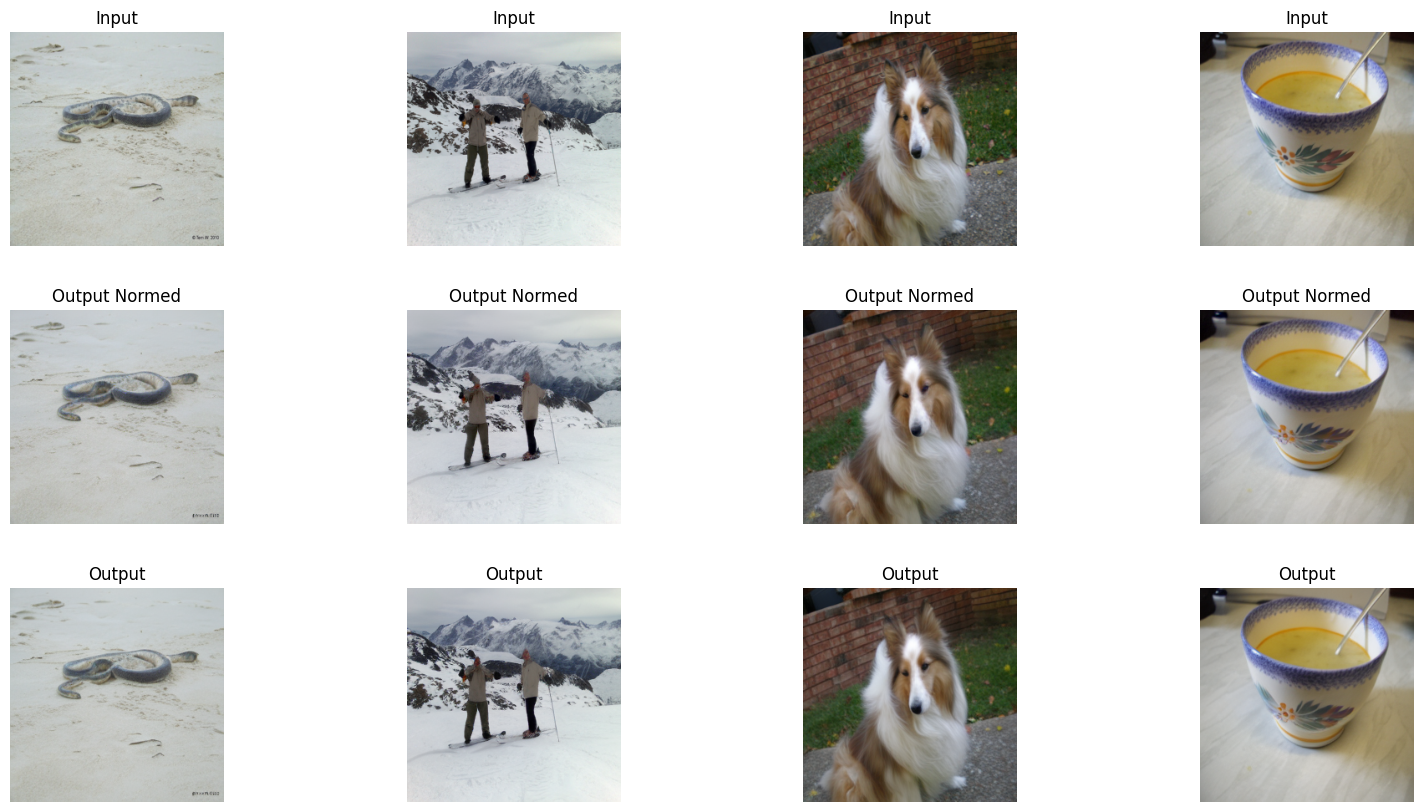

In [41]:
num_images = 4

# Corrected code
fig, axes = plt.subplots(3, num_images, figsize=(20, 10))  # Adjust figsize for larger sub-images

for i in range(num_images):
    # Plot input images (top row)
    axes[0, i].imshow(normed_bofore_in[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[0, i].set_title("Input")

    # Plot output images (bottom row)
    axes[1, i].imshow(normed_before_out[i].permute(1, 2, 0))
    axes[1, i].axis("off")
    axes[1, i].set_title("Output Normed")

    # Plot output images (bottom row)
    axes[2, i].imshow(normed_after_out[i].permute(1, 2, 0))
    axes[2, i].axis("off")
    axes[2, i].set_title("Output")

plt.subplots_adjust(wspace=0.1, hspace=0.3)  # Adjust spacing between subplots
plt.show()